In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import NearestNDInterpolator, griddata
from scipy.ndimage import gaussian_filter
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')


In [2]:

# =====================================================================
# 1. PREPROCESSING & DATA CLEANING FUNCTION
# =====================================================================
def load_and_clean(filepath, value_col):
    """
    Reads the CSV data, skips the secondary unit row, parses standard types,
    and groups time directly into Year-Month string periods.
    """
    df = pd.read_csv(filepath, skiprows=[1])
    
    # Standardize explicit data types across files
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    
    # Drop rows missing structural coordinates or parameter observations
    df = df.dropna(subset=['time', 'latitude', 'longitude', value_col])
    
    # Track everything by year-month periods
    df['year_month'] = df['time'].dt.to_period('M')
    return df

print("1. Loading and cleaning datasets...")
df_chloro = load_and_clean('../data/raw/Klorofil2023-2025.csv', 'chlor_a')
df_salinity = load_and_clean('../data/raw/Salinitas2023-2025.csv', 'sss')
df_suhu = load_and_clean('../data/raw/Suhu2023-2025.csv', 'analysed_sst')


1. Loading and cleaning datasets...


In [3]:

# =====================================================================
# 2. SEASON ASSIGNMENT
# =====================================================================
def assign_season(dt):
    """
    Assigns Indonesian monsoonal seasons.
    December belongs to next year's season block by convention.
    """
    month = dt.month
    if month in [12, 1, 2]:
        return 'Musim Barat'
    elif month in [3, 4, 5]:
        return 'Musim Peralihan 1'
    elif month in [6, 7, 8]:
        return 'Musim Timur'
    else:
        return 'Musim Peralihan 2'

print("2. Assigning seasonal blocks...")
df_chloro['season'] = df_chloro['time'].apply(assign_season)


2. Assigning seasonal blocks...


In [4]:

# =====================================================================
# 3. INTERPOLATION-BASED SPATIAL-TEMPORAL DATA MERGING
# =====================================================================
print("3. Aligning spatial grids using nearest-neighbor interpolation...")

merged_records = []

# Group the Chlorophyll file by Year-Month to serve as our grid baseline structure
for ym, chl_sub in df_chloro.groupby('year_month'):
    # Extract matching month data from Salinity and Temperature datasets
    sal_sub = df_salinity[df_salinity['year_month'] == ym]
    suhu_sub = df_suhu[df_suhu['year_month'] == ym]
    
    # Skip months where one of the datasets has no recordings
    if sal_sub.empty or suhu_sub.empty:
        continue
        
    # Average coordinates if there are duplicate daily snapshots in the same month
    chl_agg = chl_sub.groupby(['latitude', 'longitude', 'season'])['chlor_a'].mean().reset_index()
    sal_agg = sal_sub.groupby(['latitude', 'longitude'])['sss'].mean().reset_index()
    sst_agg = suhu_sub.groupby(['latitude', 'longitude'])['analysed_sst'].mean().reset_index()
    
    # Create 2D nearest-neighbor spatial maps using the coordinates from Salinity and SST
    interp_sal = NearestNDInterpolator(sal_agg[['latitude', 'longitude']].values, sal_agg['sss'].values)
    interp_sst = NearestNDInterpolator(sst_agg[['latitude', 'longitude']].values, sst_agg['analysed_sst'].values)
    
    # Grab the exact coordinates of our Chlorophyll data points
    chl_coords = chl_agg[['latitude', 'longitude']].values
    
    # Map the corresponding SST and Salinity values directly onto the Chlorophyll data coordinates
    chl_agg['sss'] = interp_sal(chl_coords)
    chl_agg['analysed_sst'] = interp_sst(chl_coords)
    chl_agg['year_month'] = ym
    
    merged_records.append(chl_agg)

if len(merged_records) == 0:
    raise ValueError("CRITICAL: Master dataset is empty. Verify that your file timestamps actually overlap between 2023 and 2025.")

df_master = pd.concat(merged_records, ignore_index=True)
print(f"--> Combined master dataset created successfully with {len(df_master)} uniform rows!")


3. Aligning spatial grids using nearest-neighbor interpolation...
--> Combined master dataset created successfully with 70042 uniform rows!


In [5]:
df_master

,latitude,longitude,season,chlor_a,sss,analysed_sst,year_month
0,-3.614588,127.98960,Musim Barat,0.274589,34.402125,29.833333,2022-12
1,-3.614588,128.40627,Musim Barat,0.267825,33.682957,29.943333,2022-12
2,-3.614588,128.61461,Musim Barat,0.264993,33.135849,29.943333,2022-12
3,-3.614588,128.82292,Musim Barat,0.170316,33.153120,30.136667,2022-12
4,-3.614588,129.03127,Musim Barat,0.145137,34.188680,30.136667,2022-12
...,...,...,...,...,...,...,...
70037,4.510412,139.03127,Musim Peralihan 2,0.060503,33.465895,30.020000,2025-11
70038,4.510412,139.23961,Musim Peralihan 2,0.078015,33.465895,30.020000,2025-11
70039,4.510412,139.44792,Musim Peralihan 2,0.073916,33.418239,29.896667,2025-11
70040,4.510412,139.65627,Musim Peralihan 2,0.072144,33.521776,29.896667,2025-11


In [6]:

# =====================================================================
# 4 & 5. FLEXIBLE SPATIAL STATISTICS CALCULATION
# =====================================================================
def calculate_spatial_statistics(df_season, use_partial=True):
    """
    Computes point-by-point Spearman correlations (Ordinary or Partial)
    and dominance index metrics while cleanly ignoring NaN variations.
    
    Parameters:
    -----------
    df_season : pd.DataFrame
        The merged master dataset for a specific season.
    use_partial : bool, default True
        If True, calculates Partial Spearman Correlation (controlling for the 3rd variable).
        If False, calculates Ordinary Spearman Correlation.
    """
    results = []
    grid_groups = df_season.groupby(['latitude', 'longitude'])
    
    # Threshold requirements matching degrees of freedom constraints
    # Partial correlation needs at least 4 points; Ordinary needs 3.
    min_samples = 4 if use_partial else 3
    
    for (lat, lon), group in grid_groups:
        if len(group) < min_samples:
            continue
            
        try:
            if use_partial:
                # Option A: Partial Correlation (using Pingouin)
                m_res = pg.partial_corr(data=group, x='analysed_sst', y='chlor_a', covar='sss', method='spearman')
                M_val = m_res['r'].values[0]
                
                n_res = pg.partial_corr(data=group, x='sss', y='chlor_a', covar='analysed_sst', method='spearman')
                N_val = n_res['r'].values[0]
            else:
                # Option B: Ordinary Correlation using native Pandas
                # This automatically handles missing values and avoids Pingouin keyword mismatches
                M_val = group['analysed_sst'].corr(group['chlor_a'], method='spearman')
                N_val = group['sss'].corr(group['chlor_a'], method='spearman')
            
            # Safety check: Skip pixel if correlation couldn't be computed (e.g., zero variance / all NaN)
            if np.isnan(M_val) or np.isnan(N_val):
                continue
                
            results.append({
                'latitude': lat, 'longitude': lon,
                'chlor_a': group['chlor_a'].mean(),
                'analysed_sst': group['analysed_sst'].mean(),
                'sss': group['sss'].mean(),
                'M': M_val, 'N': N_val,
                'dominance': M_val - N_val
            })
        except:
            # Prevents single faulty pixels from crashing the entire execution script
            continue
            
    return pd.DataFrame(results)

In [7]:
df_master = pd.DataFrame(df_master)
df_master.to_csv("../data/df_master.csv", index=False)

Generating Smoothed Mosaic Map Layout for: Musim Barat (2023-2025)


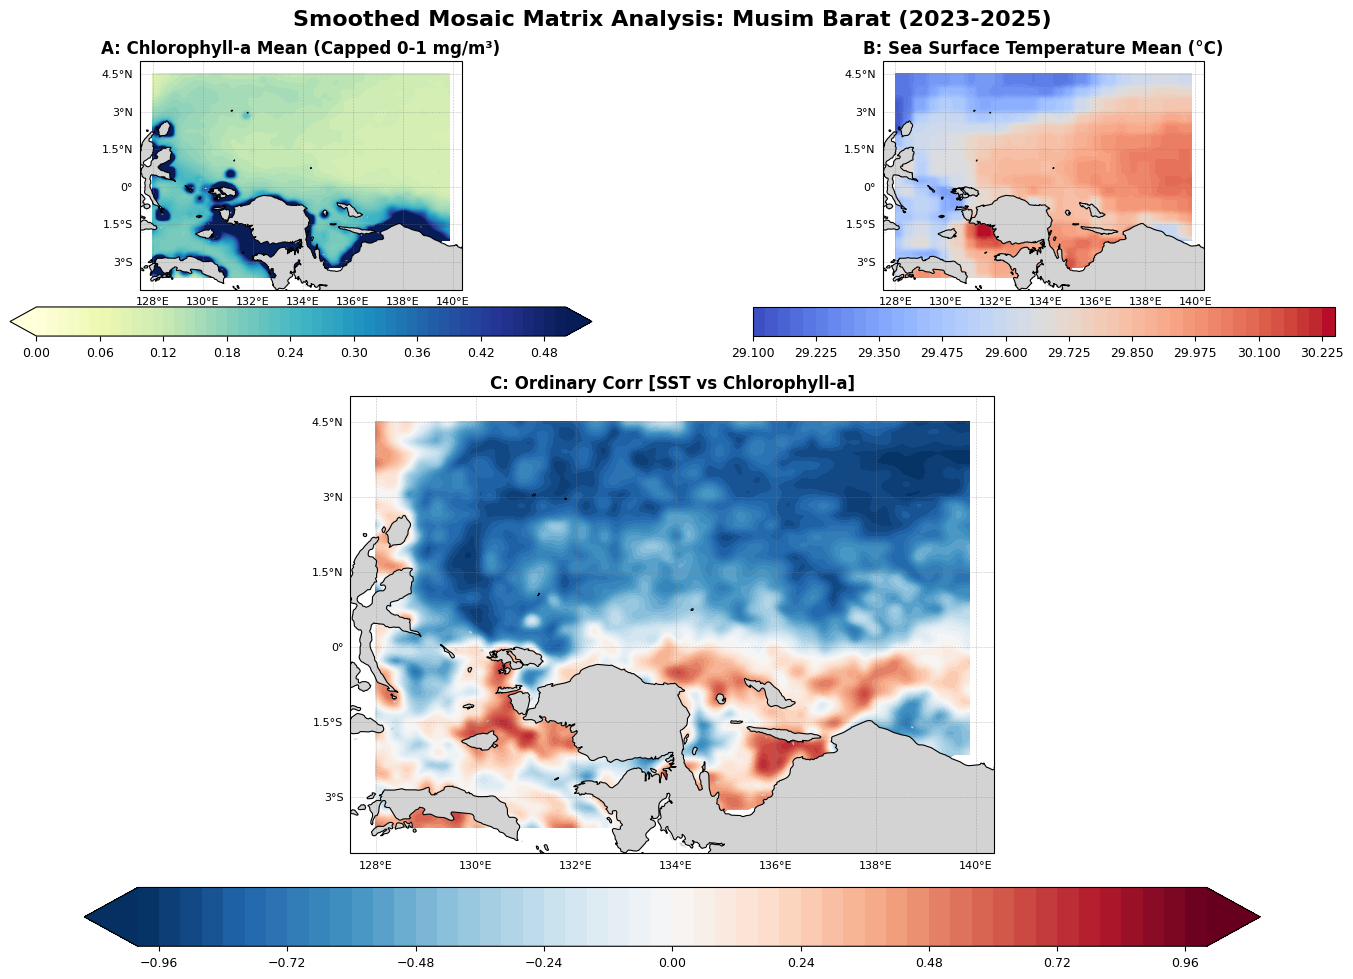

Generating Smoothed Mosaic Map Layout for: Musim Peralihan 1 (2023-2025)


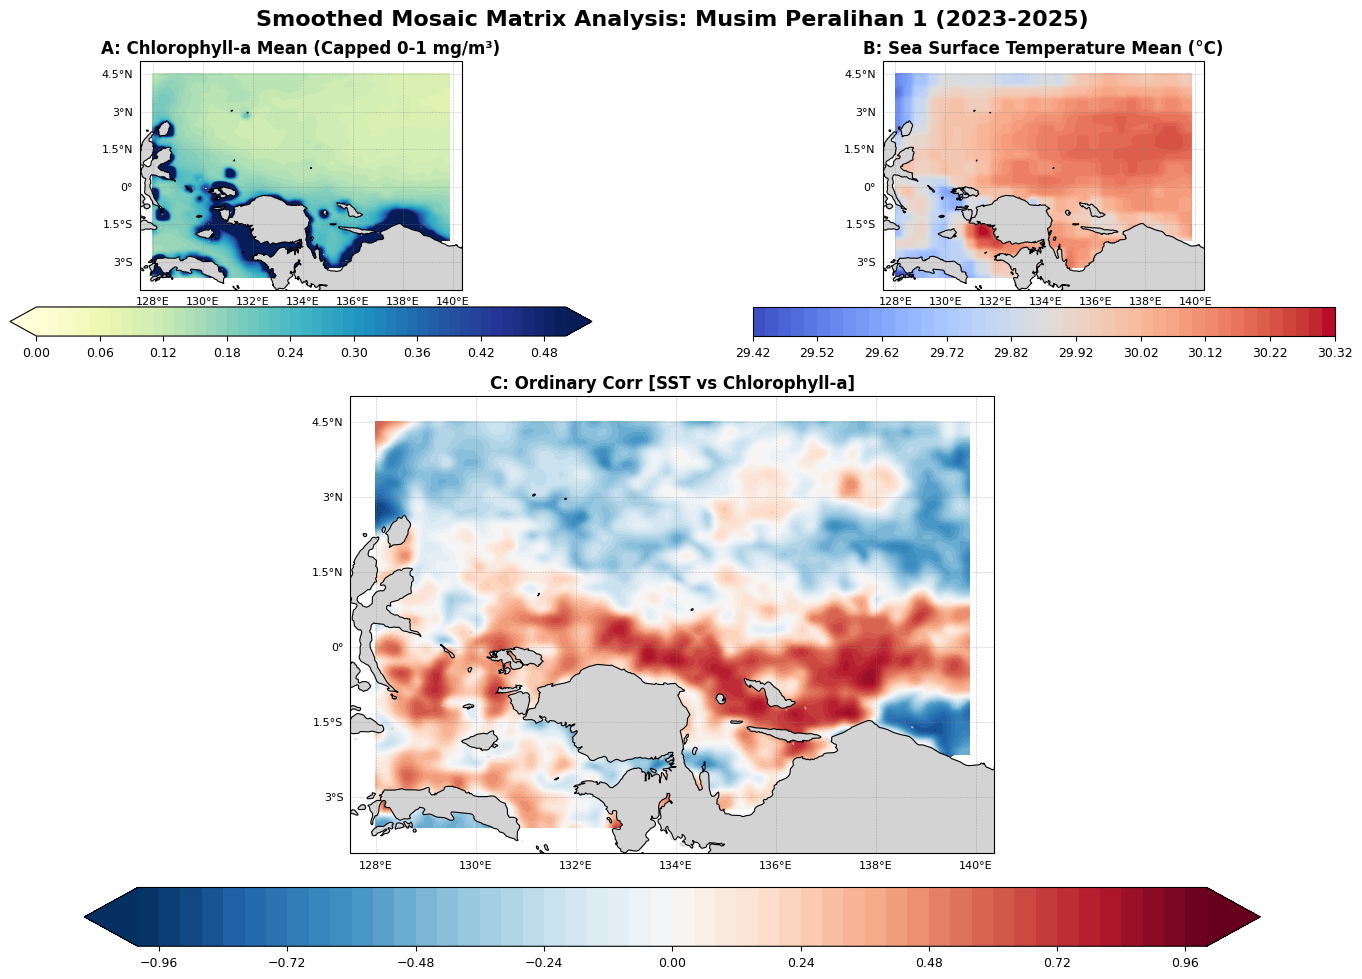

Generating Smoothed Mosaic Map Layout for: Musim Timur (2023-2025)


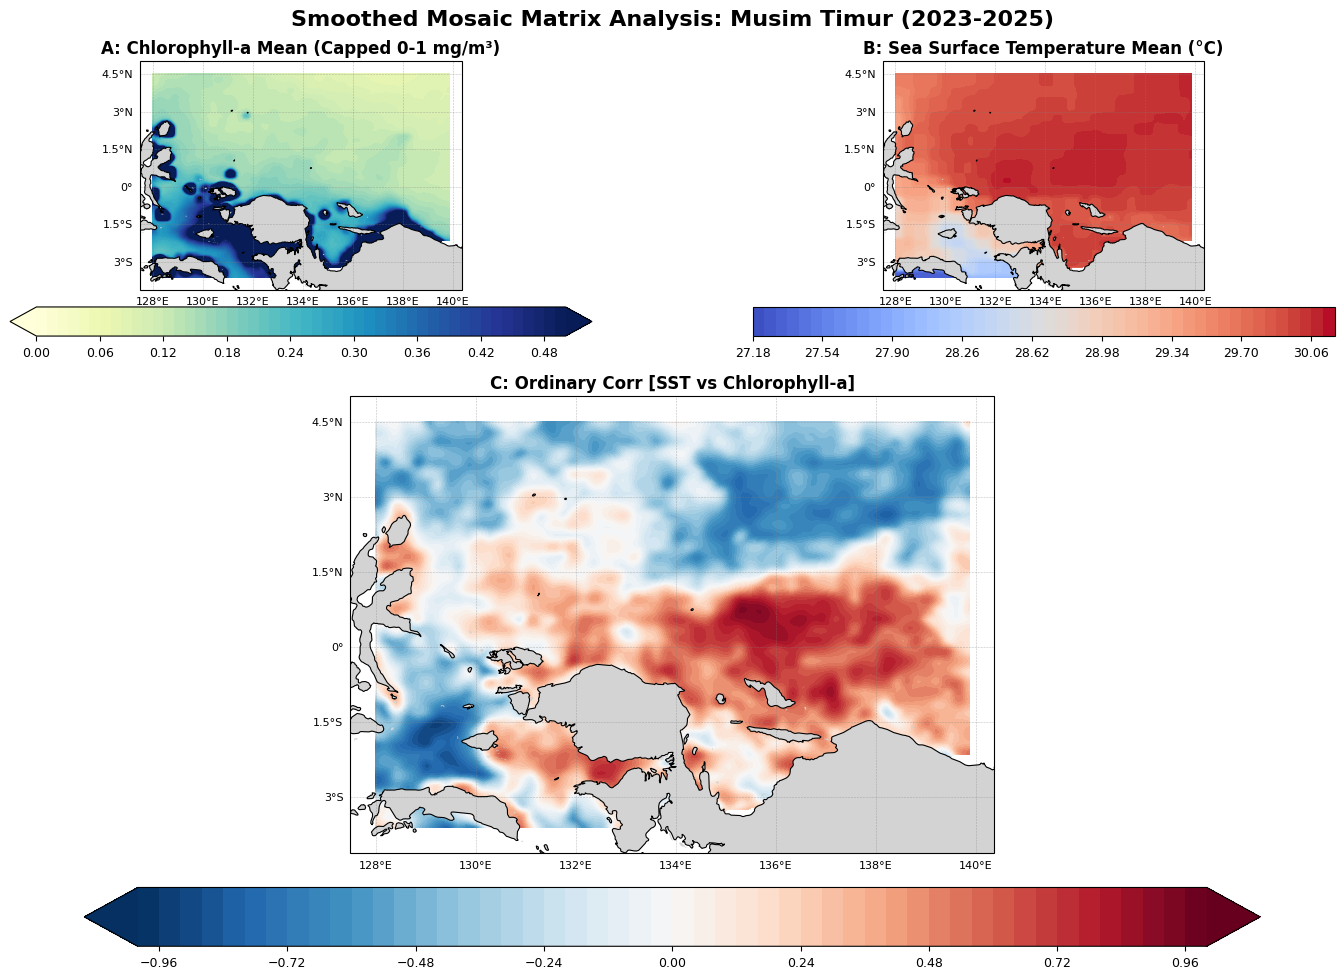

Generating Smoothed Mosaic Map Layout for: Musim Peralihan 2 (2023-2025)


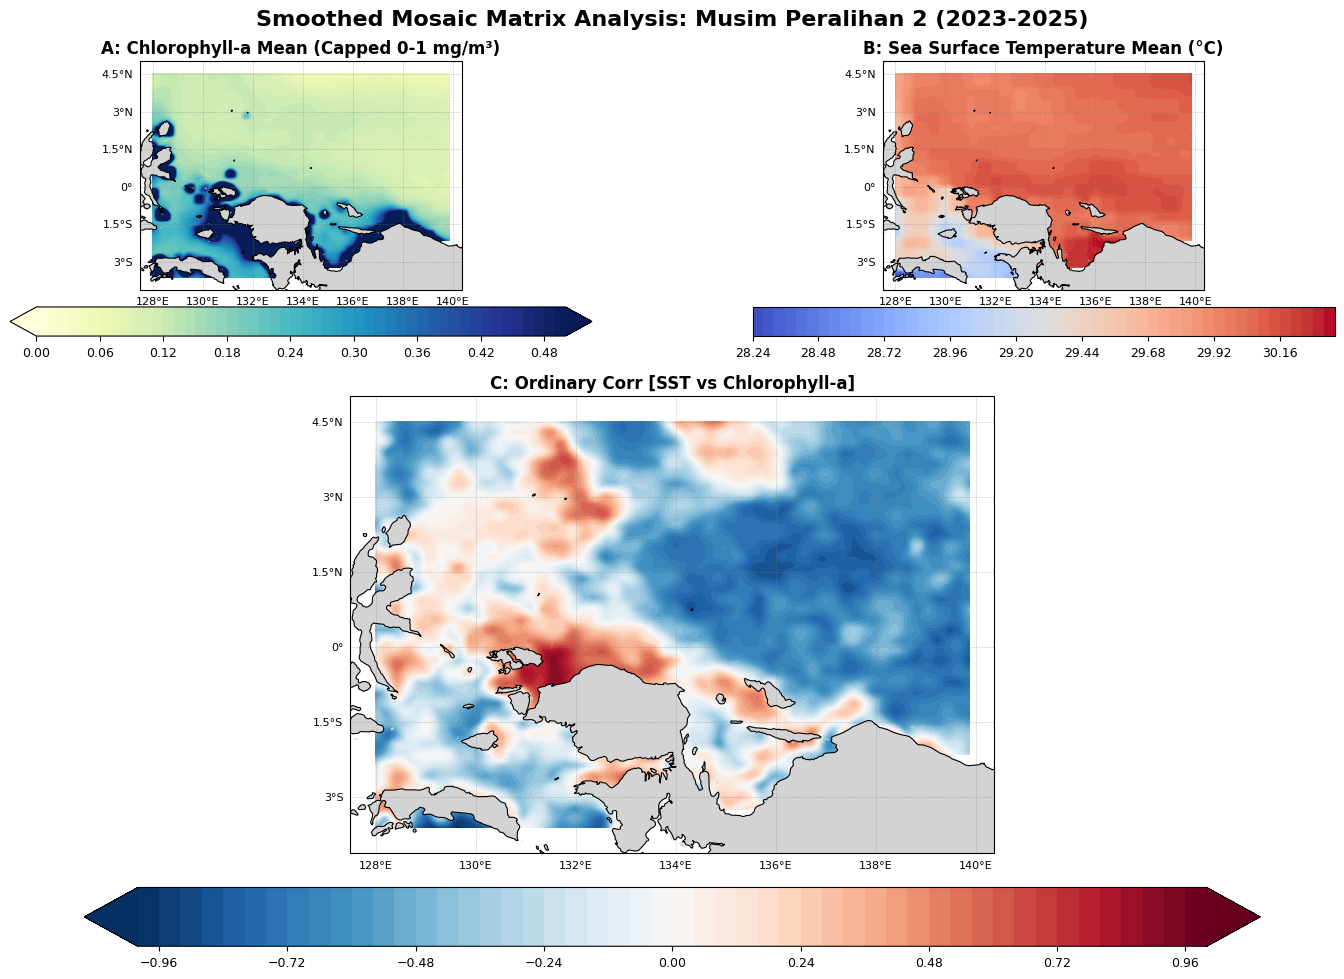

Process completed successfully.


In [8]:

# =====================================================================
# 6. SMOOTHED AB / CC MOSAIC VISUALIZATION
# =====================================================================
seasons = ['Musim Barat', 'Musim Peralihan 1', 'Musim Timur', 'Musim Peralihan 2']
crs_proj = ccrs.PlateCarree()

# CHOOSE CORRELATION TYPE: Set use_partial=True for partial, False for ordinary
RUN_PARTIAL = False 

for target_season in seasons:
    df_season_slice = df_master[df_master['season'] == target_season]
    if df_season_slice.empty:
        print(f"Skipping {target_season}: No time records match in master data.")
        continue
        
    df_plot = calculate_spatial_statistics(df_season_slice, use_partial=RUN_PARTIAL)
    
    if df_plot.empty:
        print(f"Skipping figure for {target_season}: Insufficient data points after statistical checks.")
        continue
        
    print(f"Generating Smoothed Mosaic Map Layout for: {target_season} (2023-2025)")
    
    # Cap Chlorophyll-a values strictly between 0 and 1
    df_plot['chlor_a'] = df_plot['chlor_a']
    
    # Define Mosaic configuration structure layout matrix (AB / CC)
    mosaic_layout = [
        ["A", "B"],
        ["C", "C"]
    ]
    
    fig, axd = plt.subplot_mosaic(
        mosaic_layout, 
        figsize=(15, 10), 
        subplot_kw={'projection': crs_proj},
        gridspec_kw={'height_ratios': [1, 2]}
    )
    
    corr_title = "Partial Corr (M)" if RUN_PARTIAL else "Ordinary Corr"
    fig.suptitle(f"Smoothed Mosaic Matrix Analysis: {target_season} (2023-2025)", 
                 fontsize=16, weight='bold', y=0.98)
    
    plot_configs = {
        'A': {'col': 'chlor_a', 'title': 'A: Chlorophyll-a Mean (Capped 0-1 mg/m³)', 'cmap': 'YlGnBu', 'clim': (0, 0.5)},
        'B': {'col': 'analysed_sst', 'title': 'B: Sea Surface Temperature Mean (°C)', 'cmap': 'coolwarm', 'clim': None},
        'C': {'col': 'M', 'title': f'C: {corr_title} [SST vs Chlorophyll-a]', 'cmap': 'RdBu_r', 'clim': (-1, 1)}
    }
    
    lon_min, lon_max = df_plot['longitude'].min(), df_plot['longitude'].max()
    lat_min, lat_max = df_plot['latitude'].min(), df_plot['latitude'].max()
    
    # -----------------------------------------------------------------
    # SPATIAL SMOOTHING ENGINE
    # -----------------------------------------------------------------
    # Create uniform grid tracking dimension array
    grid_lon, grid_lat = np.mgrid[lon_min:lon_max:200j, lat_min:lat_max:200j]
    points = df_plot[['longitude', 'latitude']].values
    
    for label, ax in axd.items():
        config = plot_configs[label]
        
        ax.set_extent([lon_min - 0.5, lon_max + 0.5, lat_min - 0.5, lat_max + 0.5], crs=crs_proj)
        
        # Grid interpolate coordinates onto uniform dimensions
        grid_z = griddata(points, df_plot[config['col']].values, (grid_lon, grid_lat), method='linear')
        
        # Apply Gaussian filter smoothing to remove pixel noise boundaries
        grid_z_smoothed = gaussian_filter(grid_z, sigma=1.2)
        grid_z_smoothed = np.ma.masked_invalid(grid_z_smoothed)
        
        # Cartographic background baseline attributes
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        
        if config['clim']:
            levels = np.linspace(config['clim'][0], config['clim'][1], 51)
            cf = ax.contourf(grid_lon, grid_lat, grid_z_smoothed, levels=levels,
                             cmap=config['cmap'], transform=crs_proj, extend='both', zorder=1)
        else:
            cf = ax.contourf(grid_lon, grid_lat, grid_z_smoothed, levels=51,
                             cmap=config['cmap'], transform=crs_proj, zorder=1)
            
        ax.set_title(config['title'], fontsize=12, weight='bold')
        
        cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.06, shrink=0.8)
        cbar.ax.tick_params(labelsize=9)
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 8}
        gl.ylabel_style = {'size': 8}

    plt.tight_layout()
    plt.show()

print("Process completed successfully.")

Generating Smoothed Mosaic Map Layout for: Musim Barat (2023-2025)


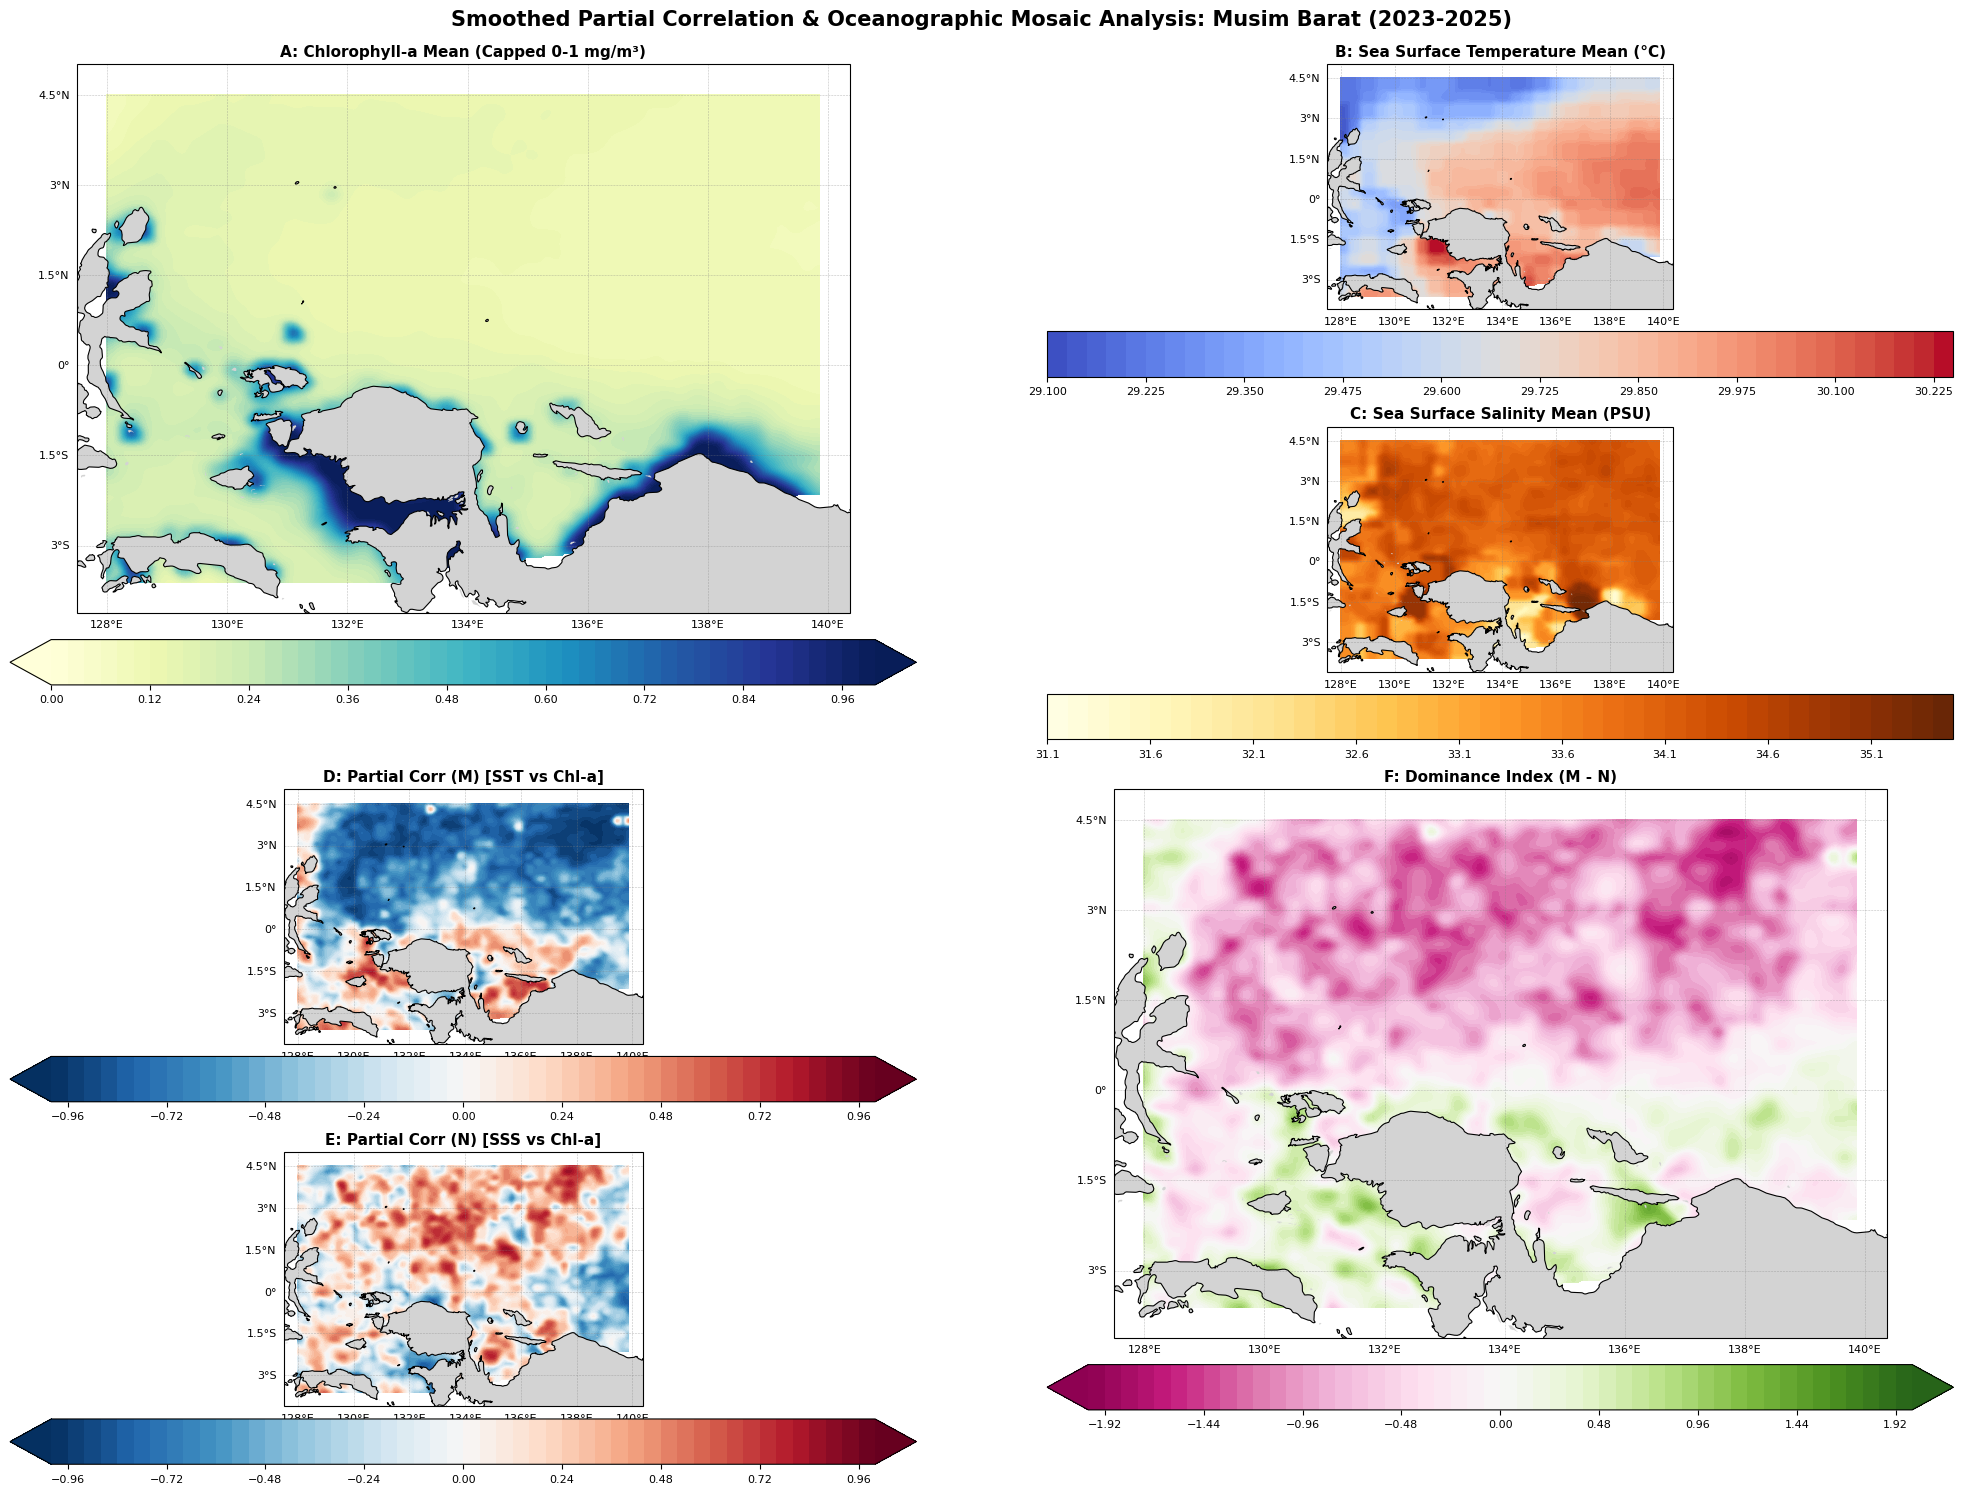

Generating Smoothed Mosaic Map Layout for: Musim Peralihan 1 (2023-2025)


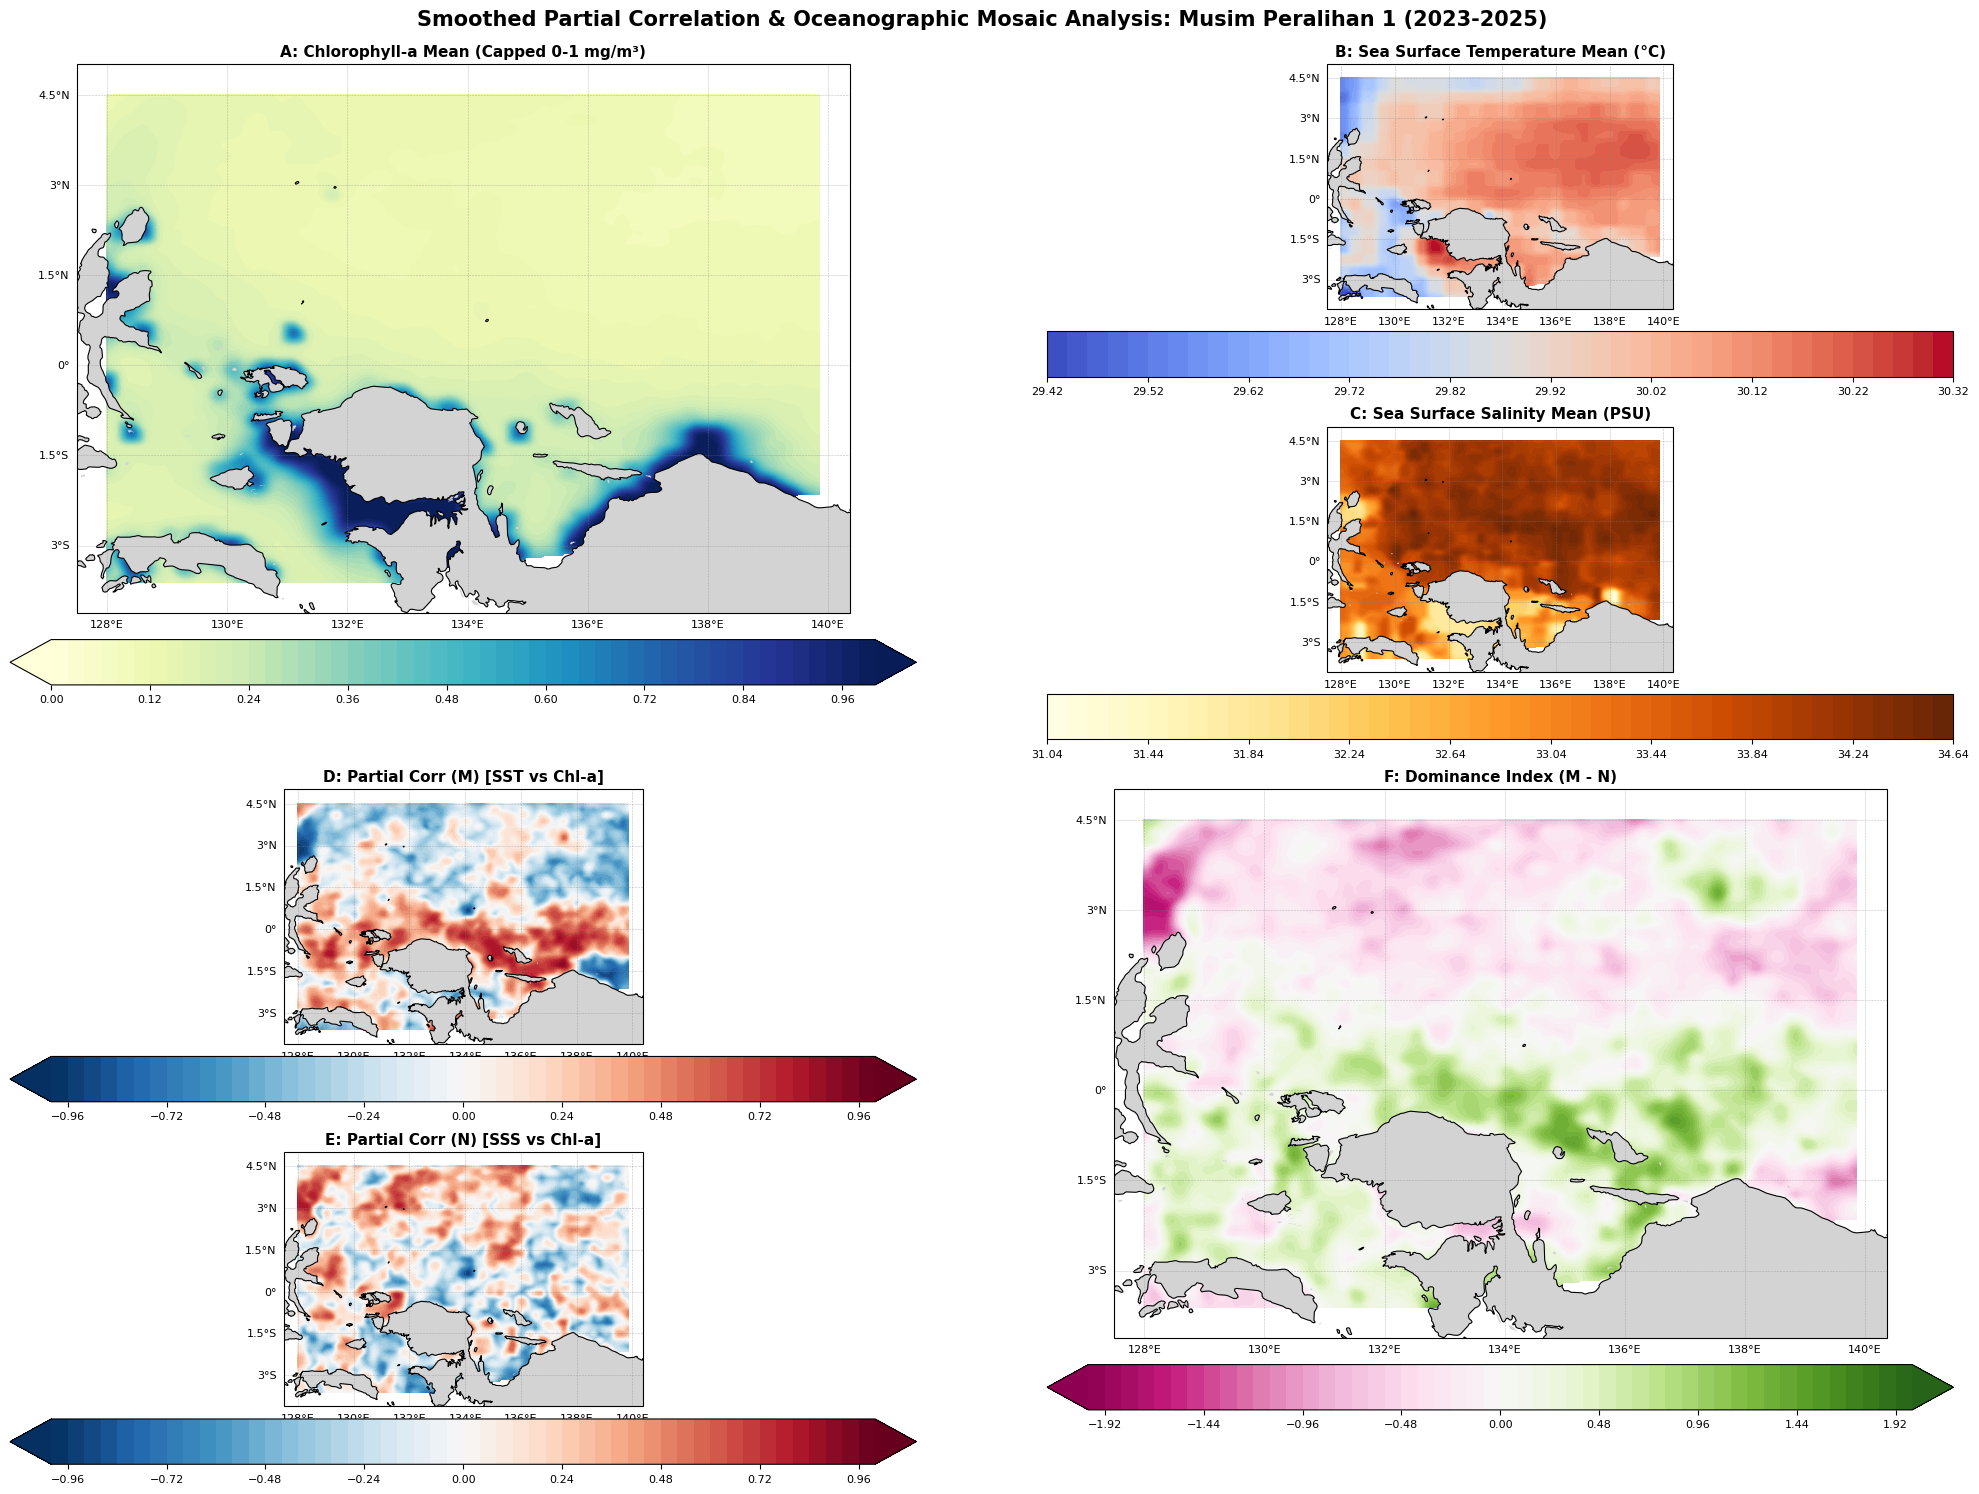

Generating Smoothed Mosaic Map Layout for: Musim Timur (2023-2025)


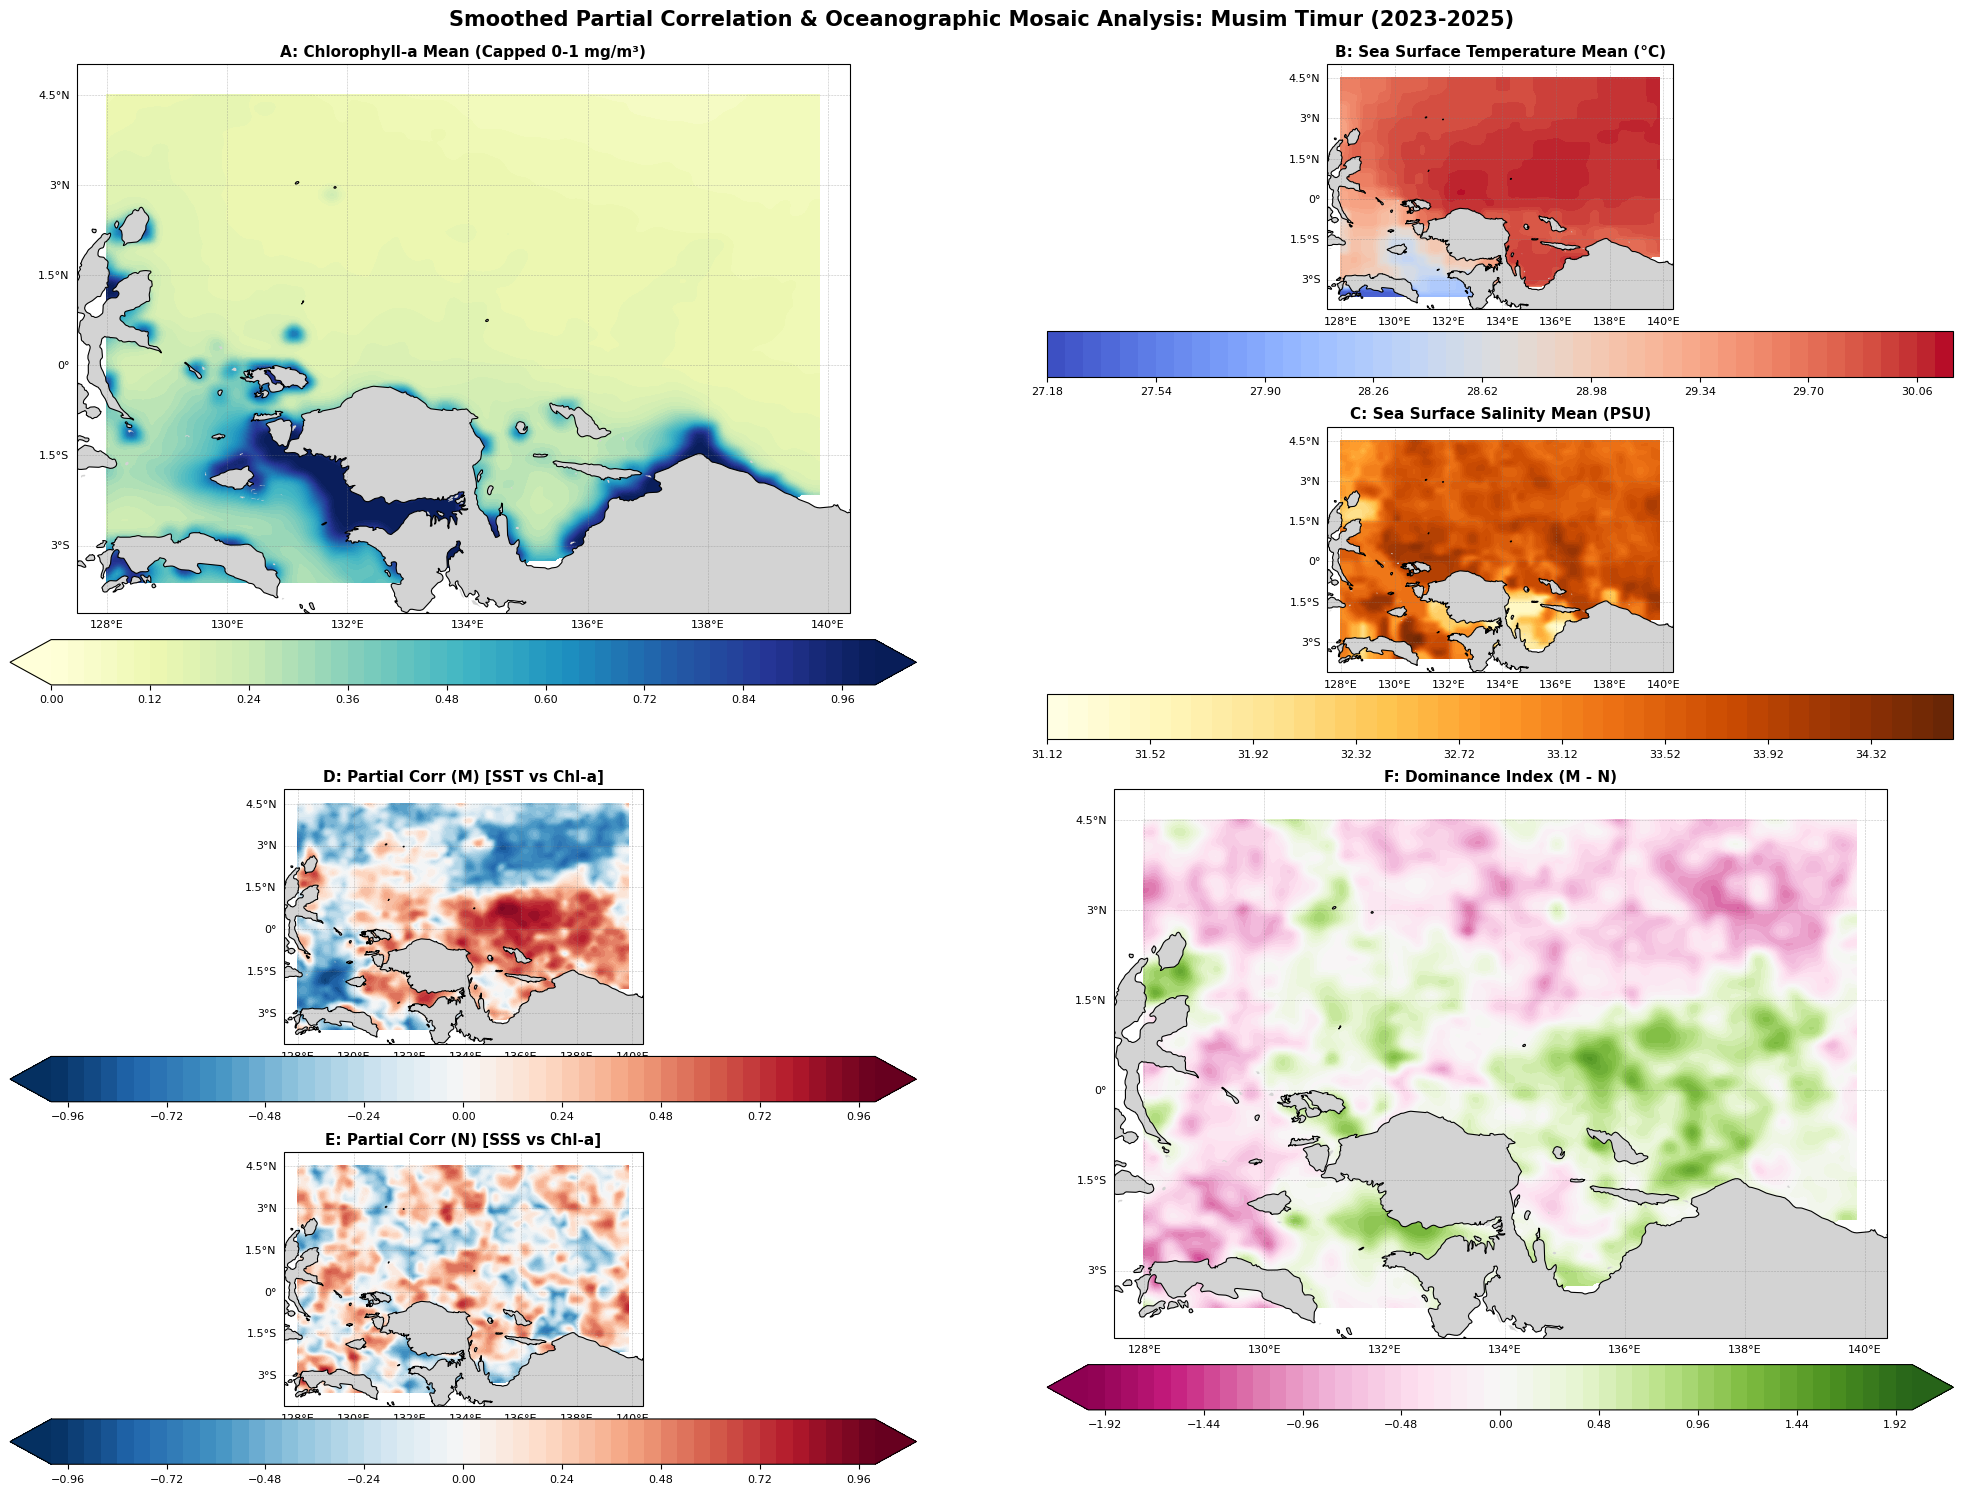

Generating Smoothed Mosaic Map Layout for: Musim Peralihan 2 (2023-2025)


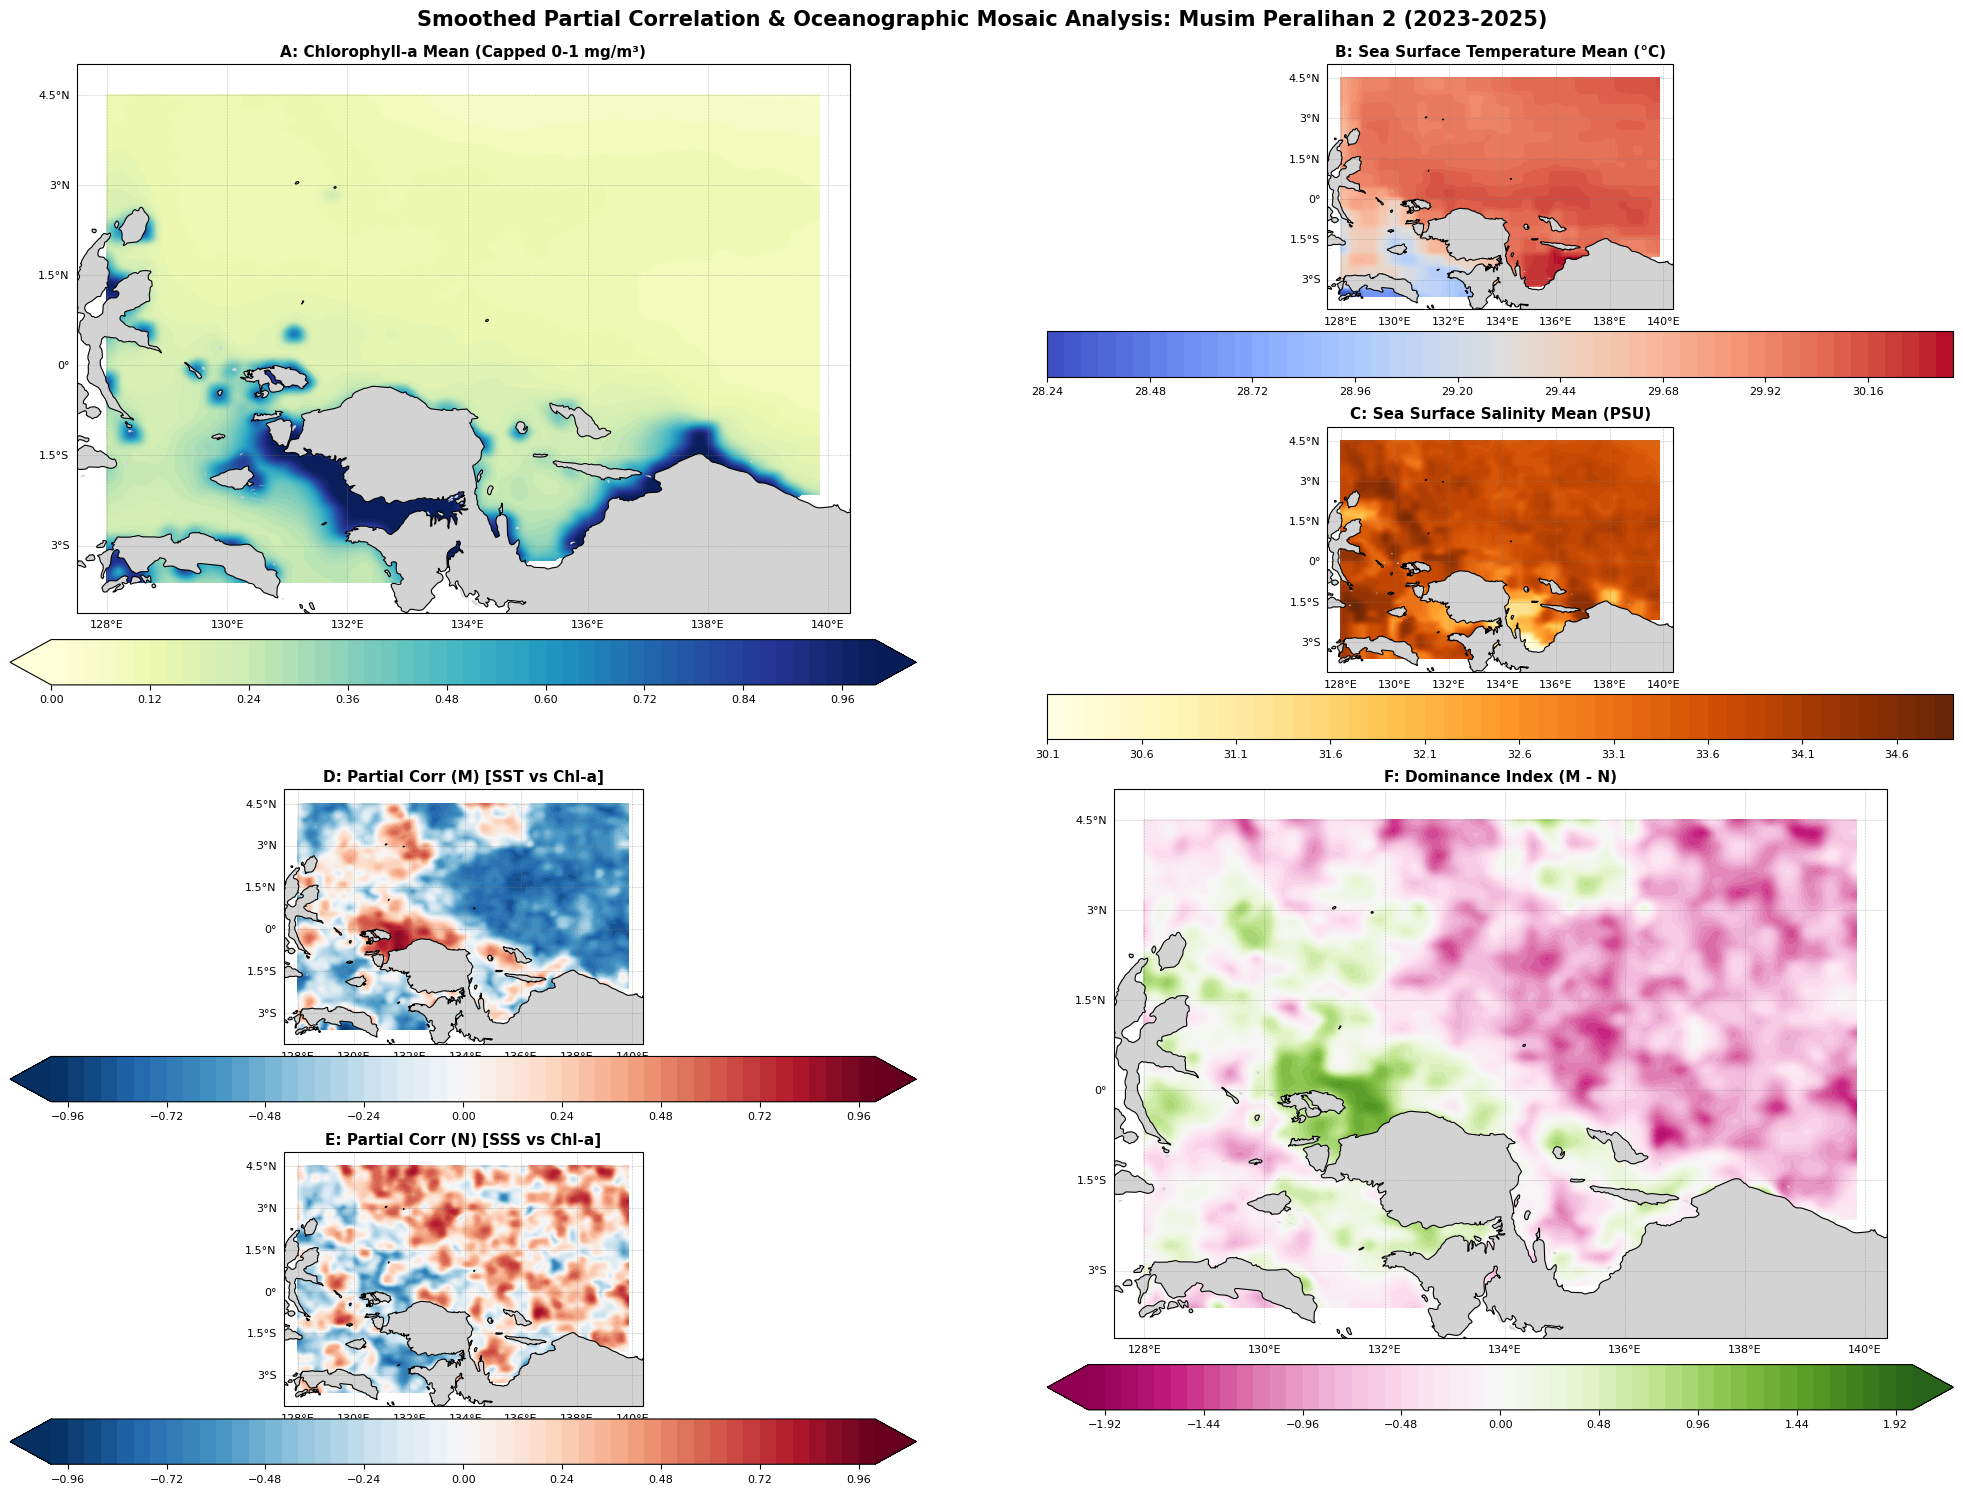

All mosaic layout figures completed successfully.


In [9]:
# =====================================================================
# 6. SMOOTHED 5-PARAMETER MOSAIC VISUALIZATION (AB / AC / DE / FE)
# =====================================================================
seasons = ['Musim Barat', 'Musim Peralihan 1', 'Musim Timur', 'Musim Peralihan 2']
crs_proj = ccrs.PlateCarree()

for target_season in seasons:
    df_season_slice = df_master[df_master['season'] == target_season]
    if df_season_slice.empty:
        print(f"Skipping {target_season}: No time records found.")
        continue
        
    df_plot = calculate_spatial_statistics(df_season_slice)
    
    if df_plot.empty:
        print(f"Skipping figure for {target_season}: Insufficient data points after statistical checks.")
        continue
        
    print(f"Generating Smoothed Mosaic Map Layout for: {target_season} (2023-2025)")
    
    # Cap Chlorophyll-a values strictly between 0 and 1
    df_plot['chlor_a'] = np.clip(df_plot['chlor_a'], 0, 1)
    
    # Define Mosaic configuration structure matrix (AB / AC / DE / FE)
    # This automatically forces 'A' and 'D' (or 'F') to combine rows vertically
    mosaic_layout = [
        ["A", "B"],
        ["A", "C"],
        ["D", "F"],
        ["E", "F"]
    ]
    
    fig, axd = plt.subplot_mosaic(
        mosaic_layout, 
        figsize=(22, 15), 
        subplot_kw={'projection': crs_proj}
    )
    
    fig.suptitle(f"Smoothed Partial Correlation & Oceanographic Mosaic Analysis: {target_season} (2023-2025)", 
                 fontsize=15, weight='bold', y=0.99)
    
    # Matrix element mapping config variables
    plot_configs = {
        'A': {'col': 'chlor_a', 'title': 'A: Chlorophyll-a Mean (Capped 0-1 mg/m³)', 'cmap': 'YlGnBu', 'clim': (0, 1)},
        'B': {'col': 'analysed_sst', 'title': 'B: Sea Surface Temperature Mean (°C)', 'cmap': 'coolwarm', 'clim': None},
        'C': {'col': 'sss', 'title': 'C: Sea Surface Salinity Mean (PSU)', 'cmap': 'YlOrBr', 'clim': None},
        'D': {'col': 'M', 'title': 'D: Partial Corr (M) [SST vs Chl-a]', 'cmap': 'RdBu_r', 'clim': (-1, 1)},
        'E': {'col': 'N', 'title': 'E: Partial Corr (N) [SSS vs Chl-a]', 'cmap': 'RdBu_r', 'clim': (-1, 1)},
        'F': {'col': 'dominance', 'title': 'F: Dominance Index (M - N)', 'cmap': 'PiYG', 'clim': (-2, 2)}
    }
    
    lon_min, lon_max = df_plot['longitude'].min(), df_plot['longitude'].max()
    lat_min, lat_max = df_plot['latitude'].min(), df_plot['latitude'].max()
    
    # -----------------------------------------------------------------
    # SPATIAL SMOOTHING ENGINE
    # -----------------------------------------------------------------
    grid_lon, grid_lat = np.mgrid[lon_min:lon_max:200j, lat_min:lat_max:200j]
    points = df_plot[['longitude', 'latitude']].values
    
    for label, ax in axd.items():
        config = plot_configs[label]
        
        ax.set_extent([lon_min - 0.5, lon_max + 0.5, lat_min - 0.5, lat_max + 0.5], crs=crs_proj)
        
        # Grid interpolation from point format onto continuous mesh
        grid_z = griddata(points, df_plot[config['col']].values, (grid_lon, grid_lat), method='linear')
        
        # Apply Gaussian filter smoothing
        grid_z_smoothed = gaussian_filter(grid_z, sigma=1.2)
        grid_z_smoothed = np.ma.masked_invalid(grid_z_smoothed)
        
        # Basemap features
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        
        # Draw filled smooth contours
        if config['clim']:
            levels = np.linspace(config['clim'][0], config['clim'][1], 51)
            cf = ax.contourf(grid_lon, grid_lat, grid_z_smoothed, levels=levels,
                             cmap=config['cmap'], transform=crs_proj, extend='both', zorder=1)
        else:
            cf = ax.contourf(grid_lon, grid_lat, grid_z_smoothed, levels=51,
                             cmap=config['cmap'], transform=crs_proj, zorder=1)
            
        ax.set_title(config['title'], fontsize=11, weight='bold')
        
        # Colorbar position padding adjustments for taller vertical multi-row figures
        cbar_pad = 0.04 if label in ['A', 'D', 'E', 'F'] else 0.07
        cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=cbar_pad, shrink=0.8)
        cbar.ax.tick_params(labelsize=8)
        
        # Format grid markings
        gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 8}
        gl.ylabel_style = {'size': 8}

    plt.tight_layout()
    plt.show()

print("All mosaic layout figures completed successfully.")